In [1]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [20]:
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# reading with csv file
movies =pd.read_csv('movies_updated.csv')

In [61]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       4000 non-null   object 
 1   rating     3960 non-null   object 
 2   genre      4000 non-null   object 
 3   year       4000 non-null   int64  
 4   released   4000 non-null   object 
 5   score      4000 non-null   float64
 6   votes      4000 non-null   int64  
 7   director   4000 non-null   object 
 8   writer     3999 non-null   object 
 9   star       3999 non-null   object 
 10  country    4000 non-null   object 
 11  budget     4000 non-null   int64  
 12  gross      3831 non-null   float64
 13  company    3990 non-null   object 
 14  runtime,,  4000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 468.9+ KB


In [63]:
# cleaning movies table data
cleanedTable = movies.copy()
# replacing the missing values from each column 
cleanedTable['budget'] = cleanedTable['budget'].astype(float)
cleanedTable.loc[:, 'budget'] = np.where(cleanedTable['budget'] == 0, np.nan, cleanedTable['budget'])
cleanedTable.loc[:, 'gross'] = np.where(cleanedTable['gross'] == 0, np.nan, cleanedTable['gross'])
cleanedTable.loc[:, "rating"] = np.where(cleanedTable["rating"] == 0, np.nan, cleanedTable["rating"])
cleanedTable.loc[:, "writer"] = np.where(cleanedTable["writer"] == None, "unknown", cleanedTable["writer"])
cleanedTable.loc[:, "star"] = np.where(cleanedTable["star"] == None, "unknown", cleanedTable["star"])
cleanedTable.loc[:, "company"] = np.where(cleanedTable["company"] == None, "unknown", cleanedTable["company"])
# Instead of: cleanedTable['budget'].fillna(cleanedTable['budget'].median(), inplace=True)
cleanedTable['budget'] = cleanedTable['budget'].fillna(cleanedTable['budget'].median())
cleanedTable['gross'] = cleanedTable['gross'].fillna(cleanedTable['gross'].mean())
cleanedTable['rating'] = cleanedTable['rating'].fillna(cleanedTable['rating'].mode()[0])

In [64]:
#Couting befor and after removing the missing values from each column
print("--- Couting befor and after removing the missing values from each column ---")
print(cleanedTable.isnull().sum())
cleanedTable = cleanedTable.dropna() 
print(cleanedTable.isnull().sum())

--- Couting befor and after removing the missing values from each column ---
name          0
rating        0
genre         0
year          0
released      0
score         0
votes         0
director      0
writer        1
star          1
country       0
budget        0
gross         0
company      10
runtime,,     0
dtype: int64
name         0
rating       0
genre        0
year         0
released     0
score        0
votes        0
director     0
writer       0
star         0
country      0
budget       0
gross        0
company      0
runtime,,    0
dtype: int64


In [11]:
# after cleaning
cleanedTable

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,"146.0,"
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,"104.0,"
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,"124.0,"
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,"88.0,"
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,"98.0,"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,O,R,Drama,2001,"August 31, 2001 (United States)",6.1,19000,Tim Blake Nelson,William Shakespeare,Mekhi Phifer,United States,5000000.0,19260537.0,Chickie the Cop,"95.0,"
3995,Birthday Girl,R,Comedy,2001,"February 1, 2002 (United States)",6.1,25000,Jez Butterworth,Tom Butterworth,Nicole Kidman,United Kingdom,13000000.0,16171098.0,FilmFour,"93.0,"
3997,Made,R,Comedy,2001,"August 31, 2001 (United States)",6.4,18000,Jon Favreau,Jon Favreau,Vince Vaughn,United States,5000000.0,5480653.0,Artisan Entertainment,"95.0,"
3998,One Night at McCool's,R,Comedy,2001,"April 27, 2001 (United States)",6.1,29000,Harald Zwart,Stan Seidel,Liv Tyler,United States,18000000.0,13578186.0,October Films,"93.0,"


In [ ]:
exercise 1

In [17]:
#Display the first five rows.
print ("the first five rows")
cleanedTable.head(5)

the first five rows


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,"146.0,"
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,"104.0,"
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,"124.0,"
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,"88.0,"
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,"98.0,"


In [19]:
#Display the number of rows and columns.
print ("number of rows x columns")
print (cleanedTable.shape)
#Display the column names.
print ("displaying the name of each column as list")
print(list(cleanedTable.columns))
#Display the data types of each column.
print ("displaying the datatype of each column")
print (cleanedTable.info())

number of rows x columns
(2547, 15)
displaying the name of each column as list
['name', 'rating', 'genre', 'year', 'released', 'score', 'votes', 'director', 'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime,,']
displaying the datatype of each column
<class 'pandas.core.frame.DataFrame'>
Index: 2547 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       2547 non-null   object 
 1   rating     2547 non-null   object 
 2   genre      2547 non-null   object 
 3   year       2547 non-null   int64  
 4   released   2547 non-null   object 
 5   score      2547 non-null   float64
 6   votes      2547 non-null   int64  
 7   director   2547 non-null   object 
 8   writer     2547 non-null   object 
 9   star       2547 non-null   object 
 10  country    2547 non-null   object 
 11  budget     2547 non-null   float64
 12  gross      2547 non-null   float64
 13  company    2547 non-null 

In [ ]:
exercise 2

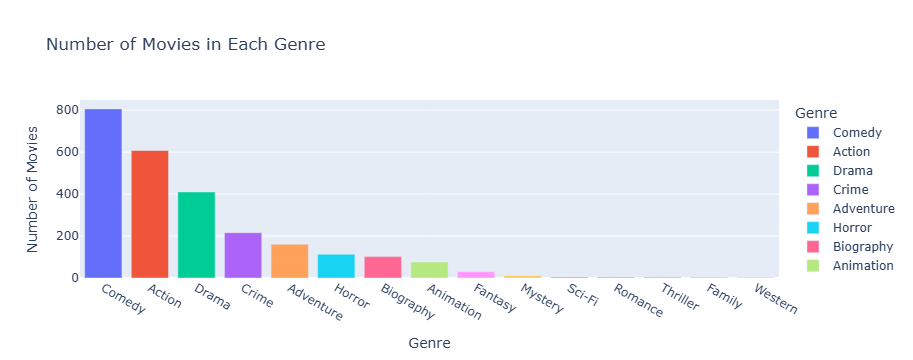

In [27]:
# creating a bar chart numofmovies x genre
genreCounts = cleanedTable['genre'].value_counts().reset_index()
genreCounts.columns = ['genre', 'movie_count']
# 3. Create the bar chart using Plotly Express
fig = px.bar(
    genreCounts,
    x='genre',
    y='movie_count',
    color='genre',  
    title='Number of Movies in Each Genre', 
    labels={
        'genre': 'Genre',               
        'movie_count': 'Number of Movies' 
    }
)
fig.show()

In [ ]:
Exercise 3

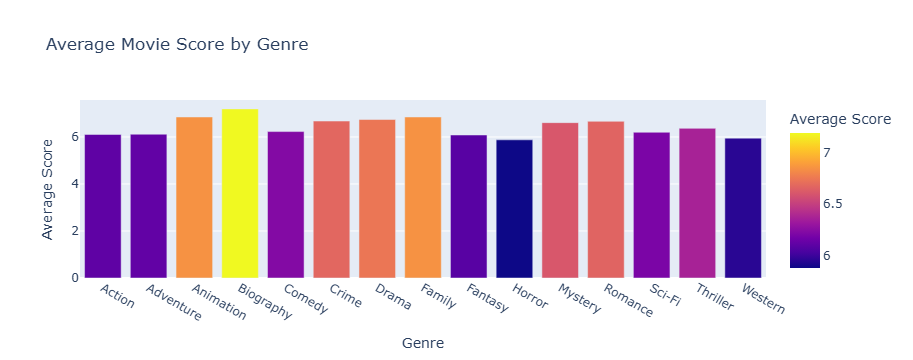

In [29]:
# 2. Calculate the average movie score for each genre
genreScores = cleanedTable.groupby('genre')['score'].mean().reset_index()
genreScores.columns = ['genre', 'average_score']

# 3. Create the bar chart
fig = px.bar(
    genreScores,
    x='genre',                  
    y='average_score',
    color='average_score',      
    title='Average Movie Score by Genre',  
    labels={
        'genre': 'Genre',
        'average_score': 'Average Score'
    }
)
fig.show()

In [ ]:
Exercise 4

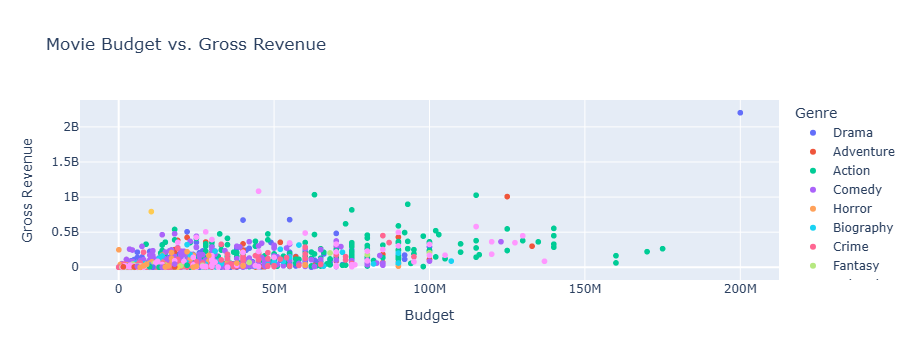

In [31]:
# Create the scatter plot
fig = px.scatter(
    cleanedTable,
    x='budget',                  
    y='gross',                 
    color='genre',              
    hover_name='name',           
    title='Movie Budget vs. Gross Revenue',  
    labels={
        'budget': 'Budget ',
        'gross': 'Gross Revenue',
        'genre': 'Genre'
    }
)

# 3. Display the chart
fig.show()

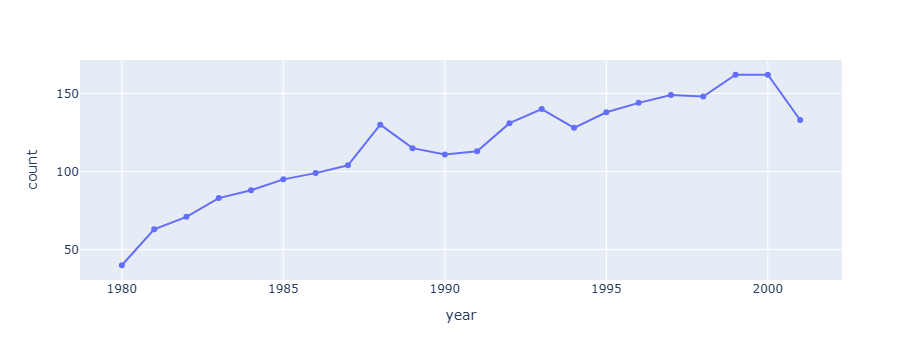

In [44]:
movieCount = cleanedTable.groupby("year")["name"].count().reset_index(name="count")
fig = px.line(movieCount, x='year', y='count', markers=True)
fig.show()

In [ ]:
Exercise 6

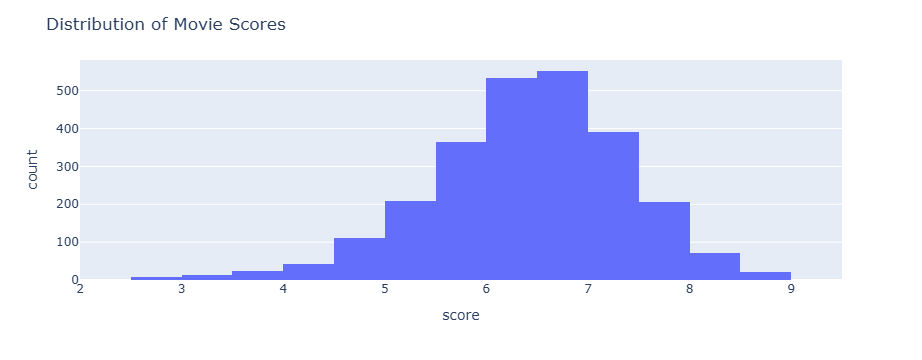

In [53]:
# histogram showing the distribution of movie scores.
df = px.data.tips()
fig = px.histogram(cleanedTable, x="score", nbins=30)
# adding chart title
fig.update_layout(
    title = 'Distribution of Movie Scores'
)
fig.show()

In [ ]:
Exercise 7

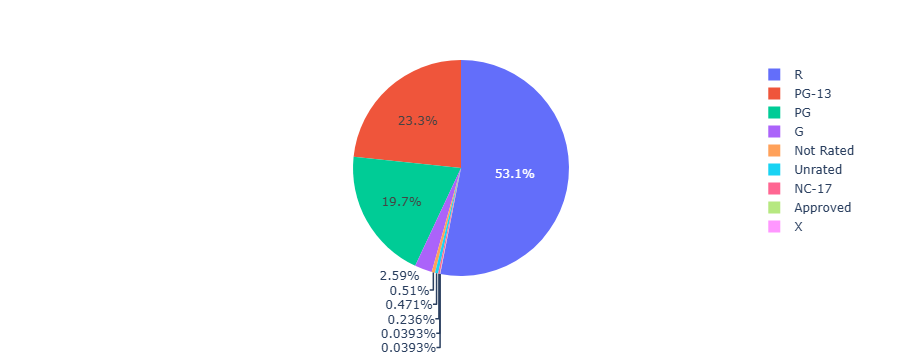

In [58]:
# Creating a pie chart
ratingCount = cleanedTable.groupby("rating")["name"].count().reset_index(name="count")
fig = px.pie(ratingCount, values='count', names='rating')
fig.show()

In [ ]:
# cleaning movies table data
cleanedTable = movies.copy()
# replacing the missing values from each column 
cleanedTable['budget'] = cleanedTable['budget'].astype(float)
cleanedTable.loc[:, 'budget'] = np.where(cleanedTable['budget'] == 0, np.nan, cleanedTable['budget'])
cleanedTable.loc[:, 'gross'] = np.where(cleanedTable['gross'] == 0, np.nan, cleanedTable['gross'])
cleanedTable.loc[:, "rating"] = np.where(cleanedTable["rating"] == 0, np.nan, cleanedTable["rating"])
cleanedTable.loc[:, "writer"] = np.where(cleanedTable["writer"] == None, "unknown", cleanedTable["writer"])
cleanedTable.loc[:, "star"] = np.where(cleanedTable["star"] == None, "unknown", cleanedTable["star"])
cleanedTable.loc[:, "company"] = np.where(cleanedTable["company"] == None, "unknown", cleanedTable["company"])
# Fill with median/mean for numerical columns
cleanedTable['budget'].fillna(cleanedTable['budget'].median(), inplace=True)
cleanedTable['gross'].fillna(cleanedTable['gross'].mean(), inplace=True)

# Fill with mode for categorical columns
cleanedTable['rating'].fillna(cleanedTable['rating'].mode()[0], inplace=True)

In [65]:
cleanedTable['company']

0                Warner Bros.
1           Columbia Pictures
2                   Lucasfilm
3          Paramount Pictures
4              Orion Pictures
                ...          
3995                 FilmFour
3996       Fine Line Features
3997    Artisan Entertainment
3998            October Films
3999    Twentieth Century Fox
Name: company, Length: 3988, dtype: object